<div style="border-left: 5px solid #794653; background-color: #f6f1ee; color: #302a28; padding: 20px 24px; margin-bottom: 22px;">
  <h1 style="color: #663c47; margin: 0 0 8px;">Winery Adventures</h1>
  <p style="font-size: 1.2em; margin: 0 0 16px;">Analisi verificabile dei dati di fermentazione</p>
  <p style="margin: 0 0 6px;">Corso di Ingegneria del Software — A.A. 2025/2026<br>
  Informatica Applicata e Data Analytics (IADA) — Università degli Studi di Cagliari</p>
  <p style="margin: 12px 0 0;"><strong>Federico Marras · Federico Franchini</strong></p>
</div>

**Winery Adventures** è una pipeline batch che trasforma letture grezze provenienti dai sensori delle cisterne in un dataset validato e arricchito, pronto per l'analisi. Riceve un TSV con istante, pH, temperatura e quantità di mosto e può integrarlo con l'anagrafica delle cisterne, che contiene capacità e vitigni associati.

Il sistema verifica prima i contratti dei dati e la coerenza degli identificativi. Calcola quindi lo stress di fermentazione per cisterna con un kernel Numba, aggiunge indicatori aggregati tramite Polars, espande ogni lettura per i vitigni associati e scrive un CSV. W&B può registrare metriche aggregate dell'esecuzione senza trasferire le letture grezze.

Il progetto non vuole formulare una diagnosi enologica: lo stress è l'indicatore numerico richiesto dalla specifica e i dati usati nella dimostrazione sono sintetici. L'obiettivo ingegneristico è mostrare come modularità, validazione, test, tracciabilità e misure riproducibili rendano affidabile e spiegabile l'intero percorso dal file di ingresso al risultato.

Durante la dimostrazione osserveremo prima il comportamento generale del sistema e poi seguiremo una cisterna campione. In questo modo le trasformazioni non restano soltanto una sequenza di metodi: potremo confrontare direttamente le sue letture di ingresso con gli indicatori e le righe prodotte nel CSV.

### Percorso della presentazione

1. [Organizzazione del lavoro](#organizzazione): pianificazione, criteri di completamento e revisione.
2. [Architettura](#architettura): responsabilità dei componenti e flusso dei dati.
3. [Dati e validazione](#dati): struttura degli input e scelta della cisterna campione.
4. [Esecuzione della pipeline](#pipeline): elaborazione generale e osservazione della cisterna campione.
5. [Casi limite](#casi-limite): riferimenti incoerenti e quantità mancanti.
6. [Prestazioni](#prestazioni): kernel Numba, ordine delle fasi e risultati misurati.
7. [Verifica](#verifica): test, copertura e integrazione continua.

In [ ]:
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Image, Markdown, display

repo_root = Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))


# Gli artefatti temporanei della demo restano in una cartella ignorata da Git.
demo_runtime_dir = repo_root / ".verification" / "demo"
wandb_runtime_dir = demo_runtime_dir / "wandb"
joblib_runtime_dir = demo_runtime_dir / "joblib"
wandb_runtime_dir.mkdir(parents=True, exist_ok=True)
joblib_runtime_dir.mkdir(parents=True, exist_ok=True)

# Le metriche restano locali durante la presentazione.
os.environ["WANDB_MODE"] = "offline"
os.environ["WANDB_SILENT"] = "true"
os.environ["WANDB_DIR"] = str(wandb_runtime_dir)
os.environ["WANDB_CACHE_DIR"] = str(wandb_runtime_dir / "cache")
os.environ["WANDB_CONFIG_DIR"] = str(wandb_runtime_dir / "config")
os.environ["JOBLIB_TEMP_FOLDER"] = str(joblib_runtime_dir)

plt.style.use("default")
plt.rcParams.update({"font.family": "DejaVu Sans", "figure.dpi": 100})
pl.Config.set_tbl_rows(14)
pl.Config.set_tbl_cols(8)
pl.Config.set_float_precision(4)

print(f"Python {sys.version.split()[0]} | Polars {pl.__version__} | NumPy {np.__version__}")
print(f"Directory di lavoro: {repo_root}")
print(f"W&B: {os.environ['WANDB_MODE']}")

Python 3.11.0 | Polars 1.44.1 | NumPy 2.4.6
Directory di lavoro: D:\isw\Winery-Adventures
W&B: offline


<a id="organizzazione"></a>
<h2 style="border-bottom: 2px solid #b9979e; padding-bottom: 9px; margin-top: 28px;">1. Organizzazione del lavoro</h2>

Lo sviluppo è organizzato con Kanban. Le 22 attività della WBS (Work Breakdown Structure, o Struttura di Scomposizione del Lavoro), da `WA-01` a `WA-22`, specificano risultato atteso, dipendenze e criteri di accettazione.

Lo **story point** è l'unità di misura convenzionale e arbitraria scelta dal gruppo per confrontare la difficoltà delle attività. Non corrisponde direttamente a ore o giorni: combina quantità di lavoro, complessità tecnica, rischio e incertezza. Nel progetto sono stati usati i valori `1`, `2`, `3`, `5` e `8`, assegnando più punti alle attività considerate relativamente più impegnative.

- La board distingue gli stati `Backlog`, `Ready`, `In Progress`, `Review / Testing` e `Done`.
- Il limite di lavoro in corso (WIP) è un'attività principale per persona.
- La stima è ripartita in 47 story point per Federico Marras e 48 per Federico Franchini.
- Il completamento richiede revisione dell'altro componente del gruppo, controlli superati e documentazione aggiornata.

Le immagini seguenti illustrano il percorso di un'attività dalla pianificazione alla revisione. Il processo è descritto in [Gestione del progetto](docs/project-management.md) e [Fasi di sviluppo](docs/development-phases.md).

### 1.1 La board

La board rende visibili lo stato delle attività e il lavoro ancora da completare.

<figure style="margin: 18px 0;">
  <img src="docs/screenshots/kanban_board.png" alt="Board Kanban del progetto" style="display: block; max-width: 100%; max-height: 760px; margin: 0 auto; border: 1px solid #c9c2be; border-radius: 4px;">
  <figcaption style="text-align: center; font-size: 0.9em; margin-top: 8px;">Figura 1. Board di Winery Adventures su GitHub Projects.</figcaption>
</figure>

Seguire il flusso da sinistra a destra: il `Backlog` contiene le attività non ancora eseguibili, mentre `Ready` raccoglie quelle che possono iniziare. `Review / Testing` rende visibile la verifica prima del completamento. La schermata documenta un momento dello sviluppo; lo stato delle singole card va letto rispetto a quel momento.

### 1.2 Come è organizzata una card

Ogni card rappresenta un'unità di lavoro reale della WBS ed è identificata da un codice `WA-XX`. Non è soltanto un promemoria: raccoglie le informazioni necessarie per capire il risultato atteso, stabilire quando il lavoro può iniziare e verificare quando può essere considerato concluso.

La parte descrittiva contiene: 

- **titolo e risultato richiesto**, che delimitano lo scopo dell'attività;
- **criteri di accettazione**, cioè le condizioni osservabili da soddisfare;
- **dipendenze**, espresse tramite i codici delle card che devono essere completate prima;
- **test richiesti**, quando il risultato può essere verificato automaticamente.

I campi della board completano la pianificazione: `Owner` assegna la responsabilità principale, `Effort` esprime la complessità relativa in story point, `Priority` indica l'urgenza, `Area` classifica il tipo di lavoro e `Status` colloca la card nel flusso Kanban.

<figure style="margin: 18px 0;">
  <img src="docs/screenshots/card_example.png" alt="Esempio della struttura di una card" style="display: block; max-width: 100%; max-height: 760px; margin: 0 auto; border: 1px solid #c9c2be; border-radius: 4px;">
  <figcaption style="text-align: center; font-size: 0.9em; margin-top: 8px;">Figura 2. Struttura di una card del progetto.</figcaption>
</figure>

Il contenuto della card costituisce un piccolo contratto di lavoro: lo scope chiarisce cosa produrre, i criteri e i test spiegano come verificarlo, mentre dipendenze e stato stabiliscono quando l'attività può avanzare. Gli story point confrontano complessità, rischio e quantità di lavoro; non rappresentano direttamente ore o giorni.

### 1.3 Pull request e peer review

Le funzionalità non vengono sviluppate direttamente su `main`. Quando inizia una card, lo sviluppatore crea un branch tematico contenente il codice `WA-XX` e mantiene le modifiche entro lo scope descritto dalla card. Lo stesso codice compare nei commit pertinenti e nel titolo della pull request, collegando pianificazione e cronologia Git anche se le unità di lavoro sono draft card e non GitHub Issues.

Al termine dell'implementazione, la pull request viene aggiunta al Project e la card passa in `Review / Testing`. L'altro componente del gruppo esegue la peer review: controlla modifiche, criteri di accettazione, test e documentazione, mentre la CI verifica automaticamente test, qualità del codice e build della documentazione. Eventuali correzioni vengono aggiunte allo stesso branch e aggiornano la pull request.

Solo dopo revisione, controlli superati e merge in `main` la card viene spostata in `Done`. In questo modo chi implementa e chi verifica non coincidono e ogni modifica conserva una traccia verificabile delle decisioni e dei controlli svolti.

<figure style="margin: 18px 0;">
  <img src="docs/screenshots/pr_review.png" alt="Esempio del processo di pull request e peer review" style="display: block; max-width: 100%; max-height: 760px; margin: 0 auto; border: 1px solid #c9c2be; border-radius: 4px;">
  <figcaption style="text-align: center; font-size: 0.9em; margin-top: 8px;">Figura 3. Esempio del processo di revisione su GitHub.</figcaption>
</figure>

La pull request è sia uno strumento tecnico sia un punto di controllo del workflow: rende visibile il diff, raccoglie la discussione, registra l'esito dei controlli automatici e richiede l'approvazione dell'altro sviluppatore prima del merge. L'immagine mostra un'applicazione concreta di questo processo, ma la procedura è stata adottata per tutte le attività di sviluppo.

<a id="architettura"></a>
<h2 style="border-bottom: 2px solid #b9979e; padding-bottom: 9px; margin-top: 28px;">2. Architettura del sistema</h2>

La suddivisione del lavoro si riflette nella separazione delle responsabilità del software. Gli analizzatori condividono il contratto `analyze_data(df) -> DataFrame`, definito dalla classe astratta `BaseWineryAnalyzer`.

| Componente | Responsabilità |
|---|---|
| `WineryTransformer` | Aggregazioni, deviazioni termiche e associazione delle letture ai vitigni |
| `WineryHPCComputations` | Calcolo dello stress per cisterna con Numba |
| `WineryPipeline` | Esecuzione degli analizzatori e registrazione delle metriche su W&B |
| `io.py` e `validation.py` | Lettura e scrittura dei file, verifica dei contratti dei dati |
| `run_full_pipeline` | Coordinamento delle fasi, a partire dal caricamento concorrente con Joblib |

I diagrammi presentano il sistema dal punto di vista dell'utilizzatore, della struttura e dell'esecuzione. Riferimento: [Architettura](docs/architecture.md).

### 2.1 Casi d'uso

Il diagramma individua gli attori e le operazioni offerte dal sistema, dalla generazione dei dati all'analisi delle letture e alla registrazione delle metriche.

<figure style="margin: 18px 0;">
  <img src="docs/diagrams/use-case-diagram.png" alt="Diagramma dei casi d'uso" style="display: block; max-width: 100%; max-height: 760px; margin: 0 auto; border: 1px solid #c9c2be; border-radius: 4px;">
  <figcaption style="text-align: center; font-size: 0.9em; margin-top: 8px;">Figura 4. Confini del sistema e interazioni con gli attori.</figcaption>
</figure>

Il Data Analyst può generare dati di prova oppure avviare la pipeline. Le estensioni indicano due opzioni già esposte dalla funzione: includere l'anagrafica con `tank_info_csv` e registrare le metriche con `project_name`. W&B è rappresentato come servizio esterno al sistema.

### 2.2 Struttura delle classi

Il contratto comune degli analizzatori permette alla pipeline di comporre le elaborazioni. Lettura dei file e validazione restano in moduli dedicati.

<figure style="margin: 18px 0;">
  <img src="docs/diagrams/class-diagram.png" alt="Diagramma delle classi" style="display: block; max-width: 100%; max-height: 760px; margin: 0 auto; border: 1px solid #c9c2be; border-radius: 4px;">
  <figcaption style="text-align: center; font-size: 0.9em; margin-top: 8px;">Figura 5. Analizzatori, orchestrazione e moduli di supporto.</figcaption>
</figure>

In alto si distinguono la classe astratta `BaseWineryAnalyzer` e il protocollo `WineryAnalyzer`. I due analizzatori ereditano dalla prima; la pipeline richiede il contratto del protocollo e conserva una sequenza di analizzatori. Il metodo comune `analyze_data` consente di eseguirli in ordine senza incorporarne la logica nella pipeline.

### 2.3 Sequenza di esecuzione

Dopo la lettura e la validazione, lo stress viene calcolato sulle letture originali. Seguono l'espansione per vitigno, la registrazione delle metriche e la scrittura del CSV.

<figure style="margin: 18px 0;">
  <img src="docs/diagrams/sequence-diagram.png" alt="Diagramma di sequenza" style="display: block; max-width: 100%; max-height: 760px; margin: 0 auto; border: 1px solid #c9c2be; border-radius: 4px;">
  <figcaption style="text-align: center; font-size: 0.9em; margin-top: 8px;">Figura 6. Flusso coordinato da `run_full_pipeline`.</figcaption>
</figure>

Il diagramma si legge dall'alto verso il basso: il blocco `par` riguarda la lettura concorrente; i blocchi `opt` indicano le operazioni condizionate dai parametri. Soffermarsi sulla validazione prima dell'HPC e sull'HPC prima del trasformatore. La scrittura del CSV conclude l'esecuzione; la funzione restituisce `None`, quindi il risultato si legge dal file.

<a id="dati"></a>
<h2 style="border-bottom: 2px solid #b9979e; padding-bottom: 9px; margin-top: 28px;">3. Dati di ingresso e validazione</h2>

La pipeline riceve due file TSV: le letture dei sensori e, facoltativamente, l'anagrafica delle cisterne.

| Dataset | Campi | Vincoli principali |
|---|---|---|
| Sensori | `tank_id`, `time`, `pH`, `temp`, `quantity_liters` | Identificativo della cisterna, istante di lettura e misure; la quantità è opzionale e può essere nulla |
| Cisterne | `tank_id`, `grape_variety`, `capacity_liters` | Identificativo univoco, vitigni separati da virgola e capacità |

Per osservare la struttura dei dati usiamo il [generatore](data_generator.py) con seed 42: cinque cisterne e 25 letture complessive. Il generatore produce pH tra 3 e 4, temperature tra 22 e 28 °C e tre vitigni per cisterna; questi intervalli descrivono i dati sintetici.

Le quantità mancanti simulano letture incomplete. Dopo aver osservato le tabelle, salviamo questi stessi dati e li passiamo alla pipeline; li riprenderemo anche nella sezione sui casi limite.

In [2]:
import random

from data_generator import generate_sensor_data, generate_tank_info, generate_variety_pool

# Il seed rende ripetibile questo esempio con le funzioni del generatore.
random.seed(42)
pool = generate_variety_pool(num_varieties=20)
tanks_data = generate_tank_info(num_tanks=5, variety_list=pool)
sensors_data = generate_sensor_data(num_tanks=5, num_readings=25, show_progress=False)

# Le tabelle mantengono i nomi delle colonne previsti dai lettori TSV.
tanks_demo = pl.DataFrame(tanks_data, schema=["tank_id", "grape_variety", "capacity_liters"], orient="row")
sensors_demo = pl.DataFrame(
    sensors_data, schema=["tank_id", "time", "pH", "temp", "quantity_liters"], orient="row"
)

print(f"Anagrafica: {tanks_demo.height} cisterne")
display(tanks_demo)
print(f"Sensori: prime 10 letture su {sensors_demo.height}")
display(sensors_demo.head(10))

Anagrafica: 5 cisterne


tank_id,grape_variety,capacity_liters
i64,str,i64
1,"""NuragusCorposo,VermentinoVellu…",1044
2,"""SemidanoBalsamico,VermentinoAn…",1387
3,"""FianoAureo,VermentinoAntico,Ni…",1643
4,"""VermentinoVellutato,NuragusCor…",1721
5,"""FianoAureo,CorteseAureo,Negroa…",1791


Sensori: prime 10 letture su 25


tank_id,time,pH,temp,quantity_liters
i64,str,f64,f64,i64
3,"""2025-01-05 11:00:00""",3.5200,24.3400,null
5,"""2025-01-01 17:00:00""",3.2100,27.2200,461
1,"""2025-01-03 12:00:00""",3.3900,26.0000,null
3,"""2025-01-09 19:00:00""",3.0600,23.9600,639
3,"""2025-01-03 00:00:00""",3.8500,26.9800,null
4,"""2025-01-11 03:00:00""",3.8300,22.1000,462
5,"""2025-01-09 10:00:00""",3.5700,25.2800,880
1,"""2025-01-03 18:00:00""",3.8700,27.6700,538
1,"""2025-01-10 06:00:00""",3.9900,22.9600,488


### 3.1 La cisterna campione nell'input

Prima di eseguire la pipeline scegliamo la cisterna con identificativo più basso. La selezione è deterministica: con lo stesso seed ritroveremo la stessa anagrafica e le stesse letture. La useremo come esempio concreto, continuando però a calcolare e presentare i risultati sull'intero dataset.

Osserviamo separatamente la sua anagrafica e le letture originali. Queste righe non contengono ancora medie, deviazioni, conteggi o stress: sono esattamente le informazioni che la pipeline dovrà validare e arricchire.

In [3]:
EXAMPLE_TANK_ID = int(tanks_demo.get_column("tank_id").min())
example_tank_info = tanks_demo.filter(pl.col("tank_id") == EXAMPLE_TANK_ID)
example_sensor_rows = sensors_demo.filter(pl.col("tank_id") == EXAMPLE_TANK_ID).sort("time")

print(f"Cisterna campione: {EXAMPLE_TANK_ID}")
print("Anagrafica")
display(example_tank_info)
print(f"Letture originali: {example_sensor_rows.height}")
display(example_sensor_rows)

Cisterna campione: 1
Anagrafica


tank_id,grape_variety,capacity_liters
i64,str,i64
1,"""NuragusCorposo,VermentinoVellu…",1044


Letture originali: 4


tank_id,time,pH,temp,quantity_liters
i64,str,f64,f64,i64
1,"""2025-01-01 01:00:00""",3.1100,25.4300,290
1,"""2025-01-03 12:00:00""",3.3900,26.0000,null
1,"""2025-01-03 18:00:00""",3.8700,27.6700,538
1,"""2025-01-10 06:00:00""",3.9900,22.9600,488


### 3.2 Dai DataFrame ai file TSV

Il generatore del progetto salva le tabelle con separatore di tabulazione. Riprendiamo lo stesso passaggio sui dati appena visualizzati e usiamo una cartella dedicata alla demo. La pipeline potrà così attraversare anche la lettura e la validazione dei file.

In [4]:
# File della dimostrazione: i dataset campione del progetto restano disponibili.
demo_dir = demo_runtime_dir
demo_dir.mkdir(parents=True, exist_ok=True)
sensors_tsv_demo = demo_dir / "sensors_demo.tsv"
tanks_tsv_demo = demo_dir / "tank_info_demo.tsv"

sensors_demo.write_csv(sensors_tsv_demo, separator="\t")
tanks_demo.write_csv(tanks_tsv_demo, separator="\t")
print(f"Sensori: {sensors_tsv_demo.relative_to(repo_root)} ({sensors_demo.height} letture)")
print(f"Cisterne: {tanks_tsv_demo.relative_to(repo_root)} ({tanks_demo.height} cisterne)")

Sensori: .verification\demo\sensors_demo.tsv (25 letture)
Cisterne: .verification\demo\tank_info_demo.tsv (5 cisterne)


<a id="pipeline"></a>
<h2 style="border-bottom: 2px solid #b9979e; padding-bottom: 9px; margin-top: 28px;">4. Esecuzione della pipeline e analisi del CSV</h2>

Passiamo dalla struttura degli input all'elaborazione completa. La funzione `run_full_pipeline` esegue nell'ordine:

1. Lettura concorrente dei TSV e validazione degli schemi.
2. Verifica che le cisterne dei sensori siano presenti nell'anagrafica.
3. Calcolo dello stress sulle letture non espanse.
4. Aggregazioni e trasformazioni con Polars, inclusa l'espansione per vitigno.
5. Registrazione delle metriche su W&B e scrittura del CSV.

Per questa esecuzione usiamo i due TSV appena generati e visualizzati. La chiamata seguente utilizza direttamente `run_full_pipeline`, il punto di ingresso già presente in `winery_adventures/main.py`. W&B registra i dati localmente, senza autenticazione. Il tempo visualizzato comprende l'intera chiamata, anche l'eventuale inizializzazione di Numba e di W&B.

In [5]:
from winery_adventures.main import run_full_pipeline

output_csv_demo = demo_dir / "demo_pipeline_output.csv"

# La pipeline legge i TSV, valida i dati, esegue gli analizzatori e scrive il CSV.
start_t = time.perf_counter()
run_full_pipeline(
    input_csv=str(sensors_tsv_demo),
    tank_info_csv=str(tanks_tsv_demo),
    output_csv=str(output_csv_demo),
    project_name="WineryAdventures-Demo",
)
elapsed_total = time.perf_counter() - start_t

# Il risultato viene riletto dal file effettivamente scritto dalla pipeline.
results_df = pl.read_csv(output_csv_demo)
print(f"Tempo complessivo: {elapsed_total:.3f} s")
print(f"CSV generato: {output_csv_demo.relative_to(repo_root)}")
print(f"Risultato: {results_df.height} righe, {results_df.width} colonne")

# Questa selezione rende visibile l'espansione di una lettura per più vitigni.
display(
    results_df.select("tank_id", "time", "grape_variety", "pH", "temp", "quantity_liters")
    .sort("tank_id", "time", "grape_variety")
    .head(12)
)

Tempo complessivo: 2.974 s
CSV generato: .verification\demo\demo_pipeline_output.csv
Risultato: 75 righe, 13 colonne


tank_id,time,grape_variety,pH,temp,quantity_liters
i64,str,str,f64,f64,i64
1,"""2025-01-01 01:00:00""","""NegroamaroStorico""",3.1100,25.4300,290
1,"""2025-01-01 01:00:00""","""NuragusCorposo""",3.1100,25.4300,290
1,"""2025-01-01 01:00:00""","""VermentinoVellutato""",3.1100,25.4300,290
1,"""2025-01-03 12:00:00""","""NegroamaroStorico""",3.3900,26.0000,null
1,"""2025-01-03 12:00:00""","""NuragusCorposo""",3.3900,26.0000,null
1,"""2025-01-03 12:00:00""","""VermentinoVellutato""",3.3900,26.0000,null
1,"""2025-01-03 18:00:00""","""NegroamaroStorico""",3.8700,27.6700,538
1,"""2025-01-03 18:00:00""","""NuragusCorposo""",3.8700,27.6700,538
1,"""2025-01-03 18:00:00""","""VermentinoVellutato""",3.8700,27.6700,538


### 4.1 Interpretazione del risultato

Dopo l'espansione, una lettura può comparire su più righe, una per vitigno associato alla cisterna. Gli indicatori per cisterna vengono riportati su ciascuna di queste righe.

| Colonna | Significato |
|---|---|
| `avg_pH_per_tank` | pH medio della cisterna |
| `tank_num_readings` | Numero di letture della cisterna prima dell'espansione |
| `temperature_deviation` | Scostamento assoluto rispetto a 26 °C |
| `temperature_deviation_scaled` | Scostamento rapportato a 1.000 litri usando la quantità disponibile |
| `grape_variety` | Singolo vitigno associato alla lettura |
| `grape_variety_num_readings` | Conteggio delle letture associate al vitigno |
| `stress_score` | Indice di stress della cisterna |

**Lettura della tabella.** I nomi e il significato delle colonne sono quelli del [contratto di output](docs/usage-guide.md#output-contract). Nelle celle successive selezioniamo questi indicatori dal CSV, distinguendo le righe espanse dalle letture originali.

### 4.2 Dimensioni del CSV e riepilogo per cisterna

Confrontiamo il numero di letture in ingresso con le righe del CSV. In questo esempio ogni cisterna ha tre vitigni: 25 letture producono quindi 75 righe. L'aumento corrisponde alle associazioni lettura-vitigno.

Per commentare pH medio, numero di letture e stress, estraiamo una sola combinazione di indicatori per cisterna. Sommare `tank_num_readings` su tutte le righe del CSV conterebbe più volte lo stesso valore.

In [6]:
display(pl.DataFrame({
    "Passaggio": ["Letture generate", "Righe nel CSV", "Cisterne nel CSV"],
    "Numero": [sensors_demo.height, results_df.height, results_df["tank_id"].n_unique()],
}))

# Gli indicatori per cisterna sono già calcolati e ripetuti sulle righe di output.
tank_summary = results_df.select(
    "tank_id", "tank_num_readings", "avg_pH_per_tank", "stress_score"
).unique().sort("tank_id")
display(tank_summary)

print(f"Letture originali riportate nei riepiloghi: {tank_summary['tank_num_readings'].sum()}")

Passaggio,Numero
str,i64
"""Letture generate""",25
"""Righe nel CSV""",75
"""Cisterne nel CSV""",5


tank_id,tank_num_readings,avg_pH_per_tank,stress_score
i64,i64,f64,f64
1,4,3.5900,10.7873
2,5,3.5140,5.7829
3,5,3.5960,8.7644
4,4,3.6700,3.6771
5,7,3.4214,3.5987


Letture originali riportate nei riepiloghi: 25


### 4.3 La cisterna campione dopo la pipeline

Torniamo ora alla cisterna scelta nella sezione 3. La pipeline ha calcolato gli indicatori sulle sue letture originali e ha poi associato ciascuna lettura a ogni vitigno dichiarato nell'anagrafica.

Il confronto seguente rende visibili tre proprietà:

- il numero di letture originali rimane disponibile in `tank_num_readings`;
- `avg_pH_per_tank` e `stress_score` sono indicatori della cisterna e quindi si ripetono sulle sue righe;
- il numero di righe finali dipende dal numero di associazioni lettura–vitigno, non da nuove misurazioni dei sensori.

Mostriamo prima un riepilogo del passaggio e poi le righe di output riferite al primo istante della cisterna, così si vede direttamente l'espansione per vitigno.

In [7]:
example_output_rows = results_df.filter(pl.col("tank_id") == EXAMPLE_TANK_ID).sort(
    "time", "grape_variety"
)
example_varieties = [
    variety.strip()
    for variety in example_tank_info.get_column("grape_variety").item().split(",")
    if variety.strip()
]
expected_output_rows = example_sensor_rows.height * len(example_varieties)

assert example_output_rows.height == expected_output_rows
assert example_output_rows.get_column("tank_num_readings").n_unique() == 1
assert int(example_output_rows.get_column("tank_num_readings").first()) == example_sensor_rows.height
assert example_output_rows.get_column("avg_pH_per_tank").n_unique() == 1
assert example_output_rows.get_column("stress_score").n_unique() == 1

example_summary = pl.DataFrame(
    {
        "Passaggio": [
            "Letture originali",
            "Vitigni associati",
            "Righe finali",
            "pH medio",
            "Stress della cisterna",
        ],
        "Valore": [
            str(example_sensor_rows.height),
            str(len(example_varieties)),
            str(example_output_rows.height),
            f"{example_output_rows.get_column('avg_pH_per_tank').first():.4f}",
            f"{example_output_rows.get_column('stress_score').first():.4f}",
        ],
    }
)
display(example_summary)

first_example_time = example_output_rows.get_column("time").min()
print(f"Prima lettura espansa nei {len(example_varieties)} vitigni della cisterna")
display(
    example_output_rows.filter(pl.col("time") == first_example_time).select(
        "tank_id",
        "time",
        "grape_variety",
        "pH",
        "avg_pH_per_tank",
        "tank_num_readings",
        "stress_score",
    )
)

Passaggio,Valore
str,str
"""Letture originali""","""4"""
"""Vitigni associati""","""3"""
"""Righe finali""","""12"""
"""pH medio""","""3.5900"""
"""Stress della cisterna""","""10.7873"""


Prima lettura espansa nei 3 vitigni della cisterna


tank_id,time,grape_variety,pH,avg_pH_per_tank,tank_num_readings,stress_score
i64,str,str,f64,f64,i64,f64
1,"""2025-01-01 01:00:00""","""NegroamaroStorico""",3.1100,3.5900,4,10.7873
1,"""2025-01-01 01:00:00""","""NuragusCorposo""",3.1100,3.5900,4,10.7873
1,"""2025-01-01 01:00:00""","""VermentinoVellutato""",3.1100,3.5900,4,10.7873


### 4.4 Conteggi per vitigno

`grape_variety_num_readings` conta le letture associate a ciascun vitigno, anche quando compare in più cisterne. Mostriamo una riga per vitigno, ordinando i conteggi dal maggiore al minore. Il totale di queste associazioni coincide con le righe espanse del CSV, mentre una lettura originale può contribuire a più vitigni.

In [8]:
# Si seleziona il conteggio prodotto dal trasformatore, senza ricalcolarlo.
variety_summary = results_df.select(
    "grape_variety", "grape_variety_num_readings"
).unique().sort(["grape_variety_num_readings", "grape_variety"], descending=[True, False])
display(variety_summary)
print(f"Associazioni lettura-vitigno: {variety_summary['grape_variety_num_readings'].sum()}")

grape_variety,grape_variety_num_readings
str,i64
"""FianoAureo""",12
"""VermentinoAntico""",10
"""NuragusCorposo""",8
"""VermentinoVellutato""",8
"""CorteseAureo""",7
"""NegroamaroOpulento""",7
"""GarganegaArmonico""",5
"""NiedderaAmbrato""",5
"""SemidanoBalsamico""",5


Associazioni lettura-vitigno: 75


### 4.5 Deviazioni termiche e quantità mancanti

La deviazione termica esprime la distanza da 26 °C; la versione scalata usa la quantità della singola lettura per rapportarla a 1.000 litri. Osserviamo le righe con gli scostamenti maggiori e poi quelle prive di quantità.

Nelle righe senza `quantity_liters`, lo scostamento assoluto resta disponibile e quello scalato è nullo. Lo stress è invece un indicatore della cisterna: viene riportato anche su queste righe, pur essendo calcolato sulle sole letture utilizzabili. Questo comportamento introduce gli esempi della sezione successiva.

In [9]:
temperature_columns = [
    "tank_id", "time", "grape_variety", "temp", "quantity_liters",
    "temperature_deviation", "temperature_deviation_scaled", "stress_score",
]
print("Righe del CSV con maggiore deviazione da 26 °C")
display(
    results_df.select(temperature_columns)
    .sort(["temperature_deviation", "tank_id", "time", "grape_variety"], descending=[True, False, False, False])
    .head(6)
)

# Il filtro mostra nel CSV come sono state conservate le letture incomplete.
missing_quantity = results_df.filter(pl.col("quantity_liters").is_null())
print(f"Quantità mancanti nell'input: {sensors_demo['quantity_liters'].null_count()}")
print(f"Righe corrispondenti nel CSV espanso: {missing_quantity.height}")
display(missing_quantity.select(temperature_columns))

Righe del CSV con maggiore deviazione da 26 °C


tank_id,time,grape_variety,temp,quantity_liters,temperature_deviation,temperature_deviation_scaled,stress_score
i64,str,str,f64,i64,f64,f64,f64
4,"""2025-01-11 03:00:00""","""NascoVigoroso""",22.1000,462,3.9000,8.4416,3.6771
4,"""2025-01-11 03:00:00""","""NuragusCorposo""",22.1000,462,3.9000,8.4416,3.6771
4,"""2025-01-11 03:00:00""","""VermentinoVellutato""",22.1000,462,3.9000,8.4416,3.6771
4,"""2025-01-03 22:00:00""","""NascoVigoroso""",22.6400,445,3.3600,7.5506,3.6771
4,"""2025-01-03 22:00:00""","""NuragusCorposo""",22.6400,445,3.3600,7.5506,3.6771
4,"""2025-01-03 22:00:00""","""VermentinoVellutato""",22.6400,445,3.3600,7.5506,3.6771


Quantità mancanti nell'input: 7
Righe corrispondenti nel CSV espanso: 21


tank_id,time,grape_variety,temp,quantity_liters,temperature_deviation,temperature_deviation_scaled,stress_score
i64,str,str,f64,i64,f64,f64,f64
3,"""2025-01-05 11:00:00""","""FianoAureo""",24.3400,null,1.6600,null,8.7644
3,"""2025-01-05 11:00:00""","""VermentinoAntico""",24.3400,null,1.6600,null,8.7644
3,"""2025-01-05 11:00:00""","""NiedderaAmbrato""",24.3400,null,1.6600,null,8.7644
1,"""2025-01-03 12:00:00""","""NuragusCorposo""",26.0000,null,0.0000,null,10.7873
1,"""2025-01-03 12:00:00""","""VermentinoVellutato""",26.0000,null,0.0000,null,10.7873
1,"""2025-01-03 12:00:00""","""NegroamaroStorico""",26.0000,null,0.0000,null,10.7873
3,"""2025-01-03 00:00:00""","""FianoAureo""",26.9800,null,0.9800,null,8.7644
…,…,…,…,…,…,…,…
3,"""2025-01-08 22:00:00""","""NiedderaAmbrato""",22.6900,null,3.3100,null,8.7644


<a id="casi-limite"></a>
<h2 style="border-bottom: 2px solid #b9979e; padding-bottom: 9px; margin-top: 28px;">5. Gestione dei casi limite</h2>

Il risultato dipende anche da come il sistema tratta input incompleti o incoerenti. Mostriamo due casi sul dataset generato nella sezione 3.

**Cisterna assente dall'anagrafica.** La verifica di copertura solleva `DataValidationError` prima del calcolo dello stress. In questo modo il successivo join non elimina letture senza segnalarlo (`REQ-60`).

**Quantità mancanti.** Le letture senza `quantity_liters` sono escluse dal calcolo dello stress, ma conservate nel risultato. Il punteggio della cisterna è propagato a tutte le sue letture. Se nessuna quantità è utilizzabile, il valore è `0.0`: indica l'assenza di coppie calcolabili (`REQ-17`, `REQ-54`).

In [10]:
from winery_adventures.computations import WineryHPCComputations
from winery_adventures.validation import DataValidationError, validate_tank_coverage

# La cisterna 999 non è presente nell'anagrafica.
corrupted_sensors = sensors_demo.with_columns(
    pl.when(pl.col("tank_id") == 1).then(999).otherwise(pl.col("tank_id")).alias("tank_id")
)
try:
    validate_tank_coverage(corrupted_sensors, tanks_demo)
except DataValidationError as err:
    print(f"Cisterna sconosciuta — errore atteso: {err}")
else:
    raise AssertionError("La validazione non ha rilevato la cisterna 999")

# Tutte le quantità della cisterna 2 sono mancanti.
sensors_with_nulls = sensors_demo.with_columns(
    pl.when(pl.col("tank_id") == 2).then(None).otherwise(pl.col("quantity_liters")).alias("quantity_liters")
)
processed = WineryHPCComputations().analyze_data(sensors_with_nulls)
score_tank2 = processed.filter(pl.col("tank_id") == 2)["stress_score"][0]
assert processed.height == sensors_with_nulls.height
assert score_tank2 == 0.0

print(f"Quantità mancanti — letture conservate: {processed.height} su {sensors_with_nulls.height}")
print(f"Stress della cisterna 2: {score_tank2} (nessuna coppia calcolabile)")
display(processed.select("tank_id", "stress_score").unique().sort("tank_id"))

Cisterna sconosciuta — errore atteso: Tank information is missing tank_id values: 999
Quantità mancanti — letture conservate: 25 su 25
Stress della cisterna 2: 0.0 (nessuna coppia calcolabile)


tank_id,stress_score
i64,f64
1,10.7873
2,0.0000
3,8.7644
4,3.6771
5,3.5987


<a id="prestazioni"></a>
<h2 style="border-bottom: 2px solid #b9979e; padding-bottom: 9px; margin-top: 28px;">6. Prestazioni e ottimizzazione</h2>

### 6.1 Calcolo dello stress

Per ogni cisterna, il kernel confronta tutte le coppie ordinate delle $n$ letture utilizzabili:

$$
\text{stress} = \frac{1}{n^2} \sum_{i=1}^{n} \sum_{j=1}^{n}
\left(|pH_i - pH_j| + 2|temp_i - temp_j|\right)
\left(\frac{500}{quantity_i} + \frac{500}{quantity_j}\right)
$$

L'implementazione a cicli annidati ha complessità $\mathcal{O}(n^2)$ per cisterna. Numba compila il kernel e parallelizza il ciclo esterno con `prange`.

### 6.2 Confronto durante la dimostrazione

Confrontiamo lo stesso algoritmo in Python, Numba seriale e Numba parallelo su 1.500 letture, pari a 2.250.000 coppie. La compilazione viene eseguita prima della misura e i risultati vengono confrontati entro una tolleranza numerica.

La cella effettua una sola misura per variante: serve a illustrare il comportamento sulla macchina della presentazione. Le misure ripetute e le condizioni degli esperimenti sono documentate nel [rapporto sui benchmark](docs/benchmark-report.md).

**Lettura del grafico.** L’asse dei tempi è logaritmico: permette di confrontare valori di ordini di grandezza diversi. Il confronto tra Python e Numba seriale evidenzia l’effetto della compilazione; quello tra le due varianti Numba evidenzia il contributo del parallelismo su questo carico.

In [11]:
import numba

from winery_adventures.computations import pairwise_stress_function

# Le tre varianti condividono il corpo della funzione.
py_kernel = pairwise_stress_function.py_func
serial_numba_kernel = numba.njit(parallel=False)(py_kernel)
parallel_numba_kernel = pairwise_stress_function

# Dati identici per le tre varianti.
N_READINGS = 1500
np.random.seed(42)
test_ph = np.random.uniform(3.0, 4.0, N_READINGS)
test_temp = np.random.uniform(22.0, 28.0, N_READINGS)
test_qty = np.random.uniform(500.0, 1500.0, N_READINGS)

# Compilazione esclusa dal tempo misurato.
_ = serial_numba_kernel(test_ph[:5], test_temp[:5], test_qty[:5])
_ = parallel_numba_kernel(test_ph[:5], test_temp[:5], test_qty[:5])

# 1. Esecuzione Python Puro
t0 = time.perf_counter()
res_py = py_kernel(test_ph, test_temp, test_qty)
time_py = time.perf_counter() - t0

# 2. Esecuzione Numba Seriale
t0 = time.perf_counter()
res_serial = serial_numba_kernel(test_ph, test_temp, test_qty)
time_serial = time.perf_counter() - t0

# 3. Esecuzione Numba Parallelo (Multithread con prange)
t0 = time.perf_counter()
res_parallel = parallel_numba_kernel(test_ph, test_temp, test_qty)
time_parallel = time.perf_counter() - t0

# Verifica equivalenza numerica tra i risultati (tolleranza float)
assert np.isclose(res_py, res_serial, rtol=1e-10, atol=1e-10)
assert np.isclose(res_py, res_parallel, rtol=1e-10, atol=1e-10)

speedup_serial = time_py / time_serial
speedup_parallel = time_py / time_parallel

print(f"Carico: {N_READINGS} letture, {N_READINGS**2} coppie")
print(f"Thread disponibili a Numba: {numba.get_num_threads()}")
print(f"Python: {time_py * 1000:.2f} ms")
print(f"Numba seriale: {time_serial * 1000:.2f} ms ({speedup_serial:.1f} volte rispetto a Python)")
print(f"Numba parallelo: {time_parallel * 1000:.2f} ms ({speedup_parallel:.1f} volte rispetto a Python)")
print(f"Risultati equivalenti entro la tolleranza impostata. Stress: {res_parallel:.6f}")

Carico: 1500 letture, 2250000 coppie
Thread disponibili a Numba: 32
Python: 1413.75 ms
Numba seriale: 2.26 ms (624.3 volte rispetto a Python)
Numba parallelo: 0.31 ms (4561.9 volte rispetto a Python)
Risultati equivalenti entro la tolleranza impostata. Stress: 4.827210


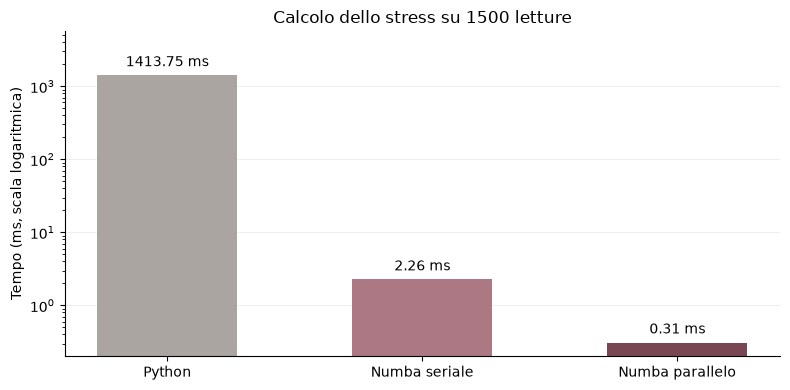

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
labels = ["Python", "Numba seriale", "Numba parallelo"]
times_ms = [time_py * 1000, time_serial * 1000, time_parallel * 1000]
bars = ax.bar(labels, times_ms, color=["#aaa5a1", "#ac7883", "#794653"], width=0.55)
ax.set_yscale("log")
ax.set_ylim(top=max(times_ms) * 4)
ax.set_ylabel("Tempo (ms, scala logaritmica)")
ax.set_title(f"Calcolo dello stress su {N_READINGS} letture")
ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
for bar, elapsed_ms in zip(bars, times_ms, strict=True):
    ax.text(
        bar.get_x() + bar.get_width() / 2, elapsed_ms * 1.2,
        f"{elapsed_ms:.2f} ms", ha="center", va="bottom"
    )
plt.tight_layout()
plt.show()

### 6.3 Ordine delle elaborazioni: WA-19

Nella versione iniziale lo stress veniva calcolato dopo l'espansione per vitigno. Con tre vitigni per cisterna, ogni lettura compariva tre volte e il kernel valutava nove volte le coppie necessarie.

La versione attuale calcola lo stress prima dell'espansione e propaga poi il punteggio alle righe dei vitigni. Anche il denominatore della formula cresceva di nove volte: il riordinamento conserva quindi il risultato matematico, con confronti software entro la tolleranza floating point.

Nel benchmark archiviato con 100 cisterne e 100.000 letture, le righe utilizzabili dal kernel passano da 270.123 a 90.041. Il tempo mediano della fase HPC scende da circa 175 a 67 ms; quello della pipeline da 336 a 222 ms. La riduzione teorica del numero di coppie va distinta dall'accelerazione misurata, pari rispettivamente a 2,59 e 1,52 volte.

Fonte: [Confronto prima e dopo il riordino](docs/benchmark-report.md#reordering-effect-wa-19-beforeafter-comparison).

### 6.4 Risultati archiviati

I due grafici seguenti mostrano il tempo complessivo e la distribuzione dei tempi tra le fasi nei benchmark archiviati. Permettono di leggere l'effetto del riordino sull'intera pipeline.

Gli esperimenti su memoria, kernel, cache Numba e Joblib sono raccolti nell'[appendice](#approfondimenti). Hanno configurazioni proprie e misurano effetti distinti; i loro fattori di accelerazione non si sommano.

#### Tempo complessivo della pipeline

Confrontare i due ordini di esecuzione: il tempo totale include anche lettura, validazione, trasformazioni e scrittura. Il beneficio dell'HPC va quindi letto insieme al costo delle altre fasi.

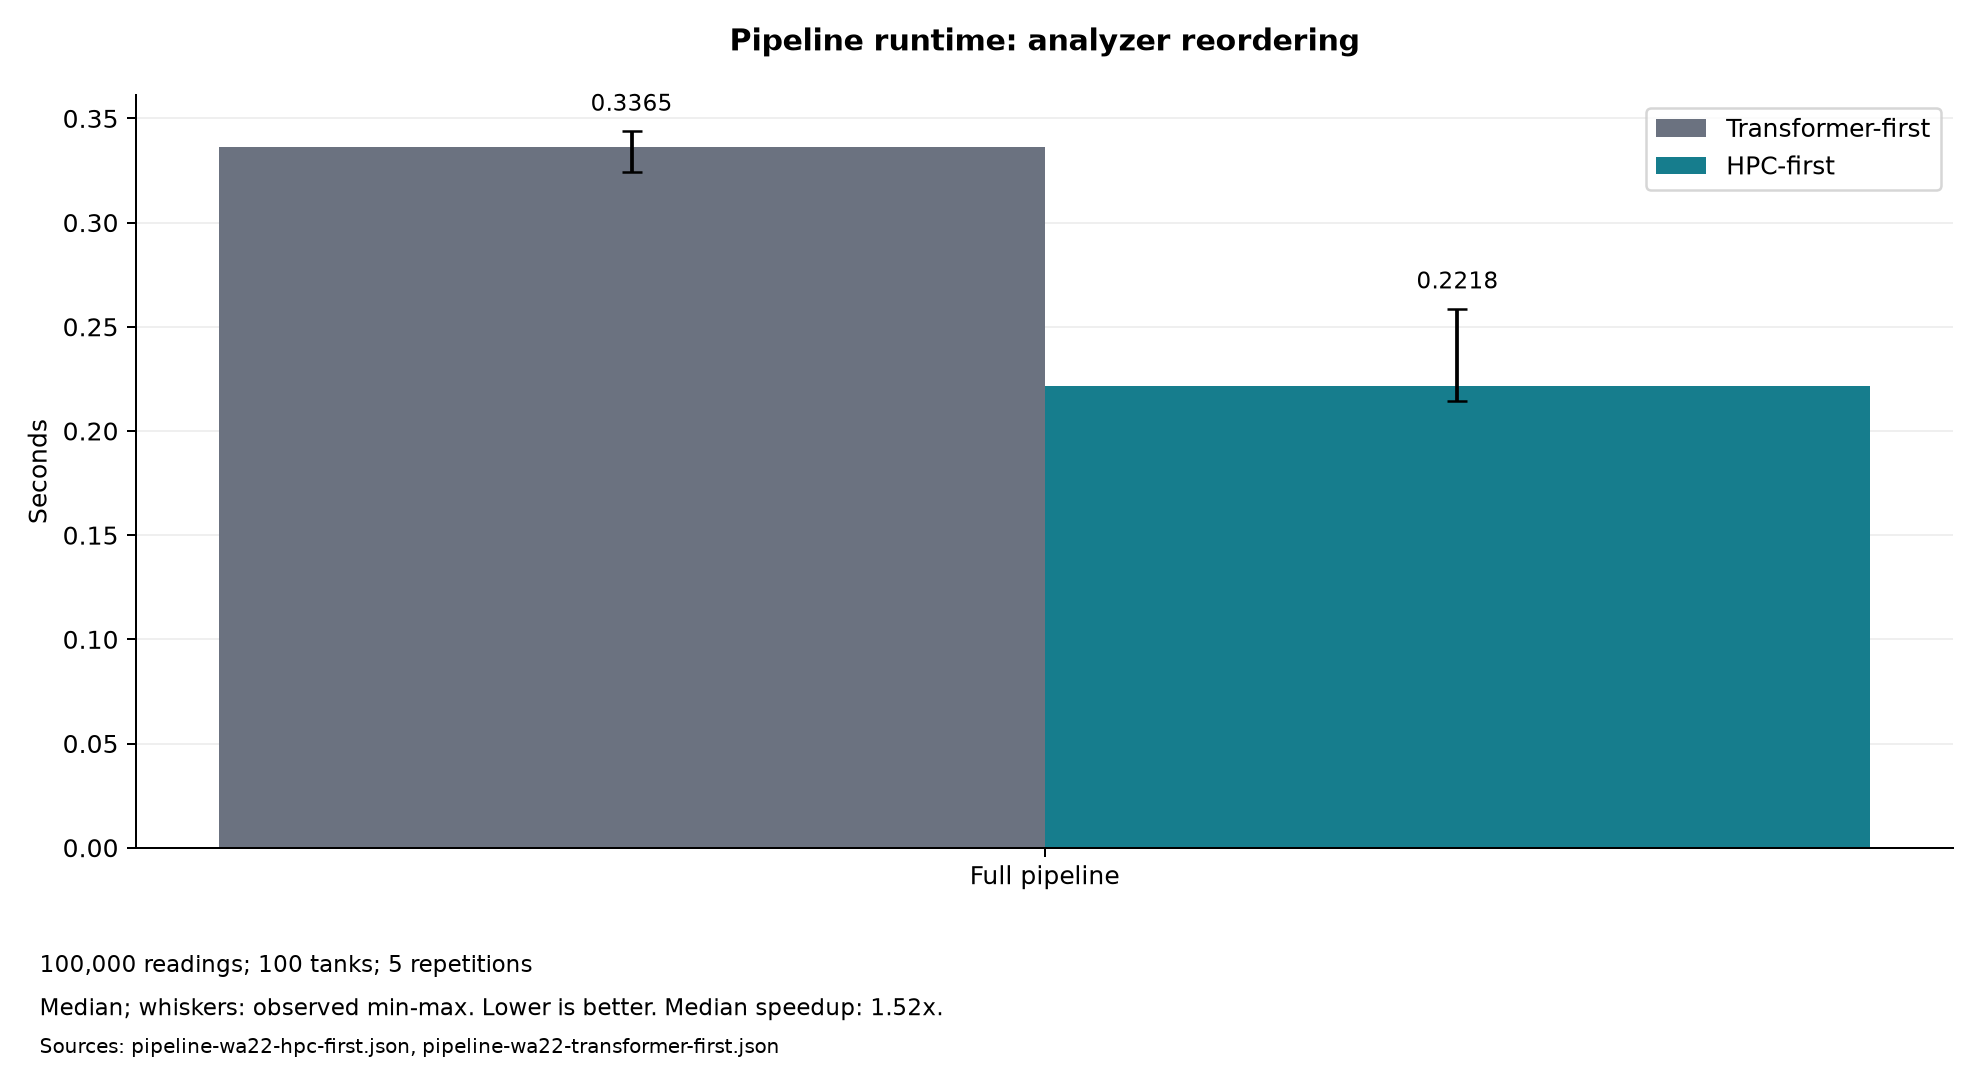

#### Tempi per fase

Individuare la fase HPC e confrontarla con le altre: il riordino interviene sulle righe sottoposte al kernel. Le mediane delle singole fasi non sono necessariamente additive rispetto alla mediana del tempo totale.

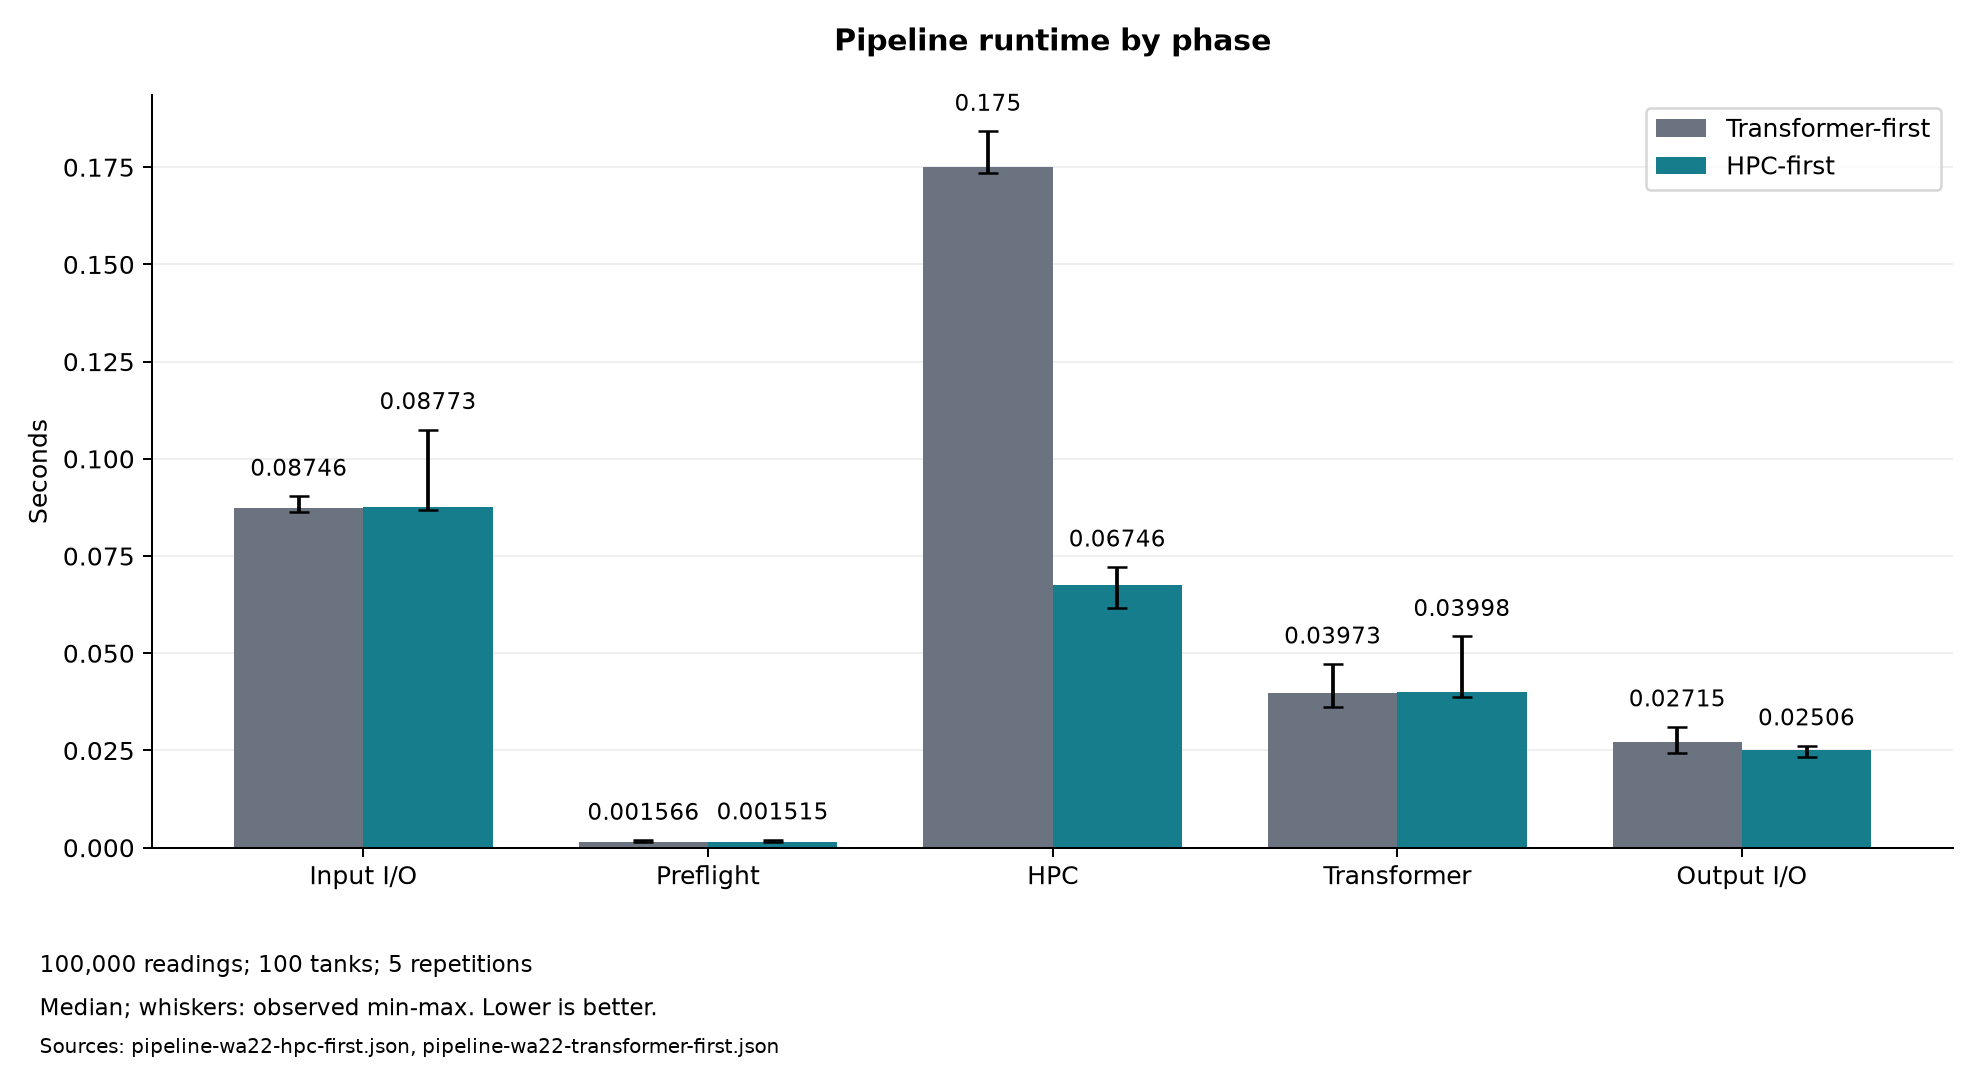

In [13]:
# I grafici sono quelli già archiviati nel progetto.
benchmark_plots = [
    (
        "Tempo complessivo della pipeline", "docs/performance-plots/pipeline-total.png",
        "Confrontare i due ordini di esecuzione: il tempo totale include anche lettura, "
        "validazione, trasformazioni e scrittura. Il beneficio dell'HPC va quindi letto "
        "insieme al costo delle altre fasi.",
    ),
    (
        "Tempi per fase", "docs/performance-plots/pipeline-phases.png",
        "Individuare la fase HPC e confrontarla con le altre: il riordino interviene "
        "sulle righe sottoposte al kernel. Le mediane delle singole fasi non sono "
        "necessariamente additive rispetto alla mediana del tempo totale.",
    ),
]
for description, image_path, reading_note in benchmark_plots:
    display(Markdown(f"#### {description}\n\n{reading_note}"))
    display(Image(filename=image_path, width=800))

<a id="verifica"></a>
<h2 style="border-bottom: 2px solid #b9979e; padding-bottom: 9px; margin-top: 28px;">7. Verifica del software</h2>

Le verifiche collegano il comportamento osservato ai requisiti del progetto. La [matrice requisiti-test](docs/requirements-tests-matrix.md) associa 69 requisiti alle relative verifiche, coprendo analizzatori, trasformazioni, calcolo dello stress, I/O, validazione, generatore e benchmark.

### 7.1 Esecuzione dei test

Durante la presentazione eseguiamo i test escludendo quelli marcati `slow`. L'output riporta il numero effettivo di test superati, esclusi o falliti; questa esecuzione non misura la copertura.

La verifica completa prevista dal progetto usa `pytest --cov`, con una soglia minima di copertura del 90% configurata in `pyproject.toml`.

In [14]:
import subprocess

print("Esecuzione dei test non marcati slow")
proc = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", "--no-header", "-m", "not slow"],
    cwd=repo_root,
    capture_output=True,
    text=True,
)
print(proc.stdout)
if proc.stderr:
    print(proc.stderr)
proc.check_returncode()

Esecuzione dei test non marcati slow


........................................................................ [ 41%]
........................................................................ [ 82%]
...............................                                          [100%]
175 passed, 2 deselected in 14.28s



### 7.2 Integrazione continua

Il [workflow GitHub Actions](.github/workflows/ci.yml) esegue i controlli sulle pull request verso `main` e sui push a `main`, oltre all'avvio manuale:

- Test con copertura su Python 3.10, 3.11, 3.12 e 3.13, in ambiente Ubuntu.
- Analisi statica con Ruff e verifica della formattazione con Black.
- Compilazione della documentazione Sphinx, trattando i warning come errori.

### 7.3 Risultati del progetto

La dimostrazione collega tre aspetti del lavoro: la tracciabilità delle attività e delle revisioni, l'elaborazione dei dati con controlli espliciti e la valutazione delle prestazioni con esperimenti documentati.

Il riordino della pipeline mostra il legame tra progettazione e prestazioni: ridurre le letture sottoposte al kernel evita calcoli ripetuti mantenendo gli indicatori richiesti. I test verificano il comportamento atteso, mentre i benchmark quantificano il beneficio nelle condizioni misurate.

<a id="conclusione"></a>
<h2 style="border-bottom: 2px solid #b9979e; padding-bottom: 9px; margin-top: 28px;">Conclusione</h2>

Il percorso ha seguito lo stesso dato dall'ingresso al risultato verificato.

- **Dal sensore al CSV.** Le 4 letture della cisterna campione sono diventate 12 righe, una per ciascuno dei vitigni associati, con le misure originali conservate.
- **Il risultato è un file, non una vista in memoria.** La tabella commentata nella sezione 4 è stata riletta dal CSV effettivamente scritto dalla pipeline.
- **I casi limite sono decisioni esplicite.** Un riferimento incoerente interrompe l'elaborazione con un errore di validazione. Una lettura con quantità mancante resta nell'output e riceve lo stress calcolato sulle letture utilizzabili della cisterna; se nessuna quantità è utilizzabile, lo stress è zero.
- **Le ottimizzazioni sono misurate.** Le tre varianti del kernel condividono formula e dati e producono lo stesso valore entro la tolleranza impostata: il confronto evidenzia l'effetto della compilazione e del parallelismo sullo stesso algoritmo.
- **Il comportamento è verificato.** La demo esegue i 175 test non marcati `slow`, escludendone 2. La CI è configurata per eseguire la suite completa con copertura su Python 3.10, 3.11, 3.12 e 3.13.

<div style="border-left: 5px solid #794653; background-color: #f6f1ee; color: #302a28; padding: 18px 22px; margin-top: 22px;">
  <strong>Winery Adventures</strong> produce un'analisi ripetibile: a parità di input e configurazione, i risultati sono confrontabili entro le tolleranze numeriche previste, considerando l'ordine delle righe non garantito. Le responsabilità dei componenti e i test rendono verificabili i passaggi della pipeline.
</div>

<a id="approfondimenti"></a>
<h2 style="border-bottom: 2px solid #b9979e; padding-bottom: 9px; margin-top: 28px;">Appendice. Esperimenti di approfondimento</h2>

I dati e le condizioni di esecuzione sono descritti nel [rapporto sui benchmark](docs/benchmark-report.md).

- **Memoria:** il picco delle allocazioni Python tracciate non rappresenta tutta la RAM del processo.
- **Kernel:** il confronto isola l'effetto della compilazione e del parallelismo.
- **Cache Numba:** l'esperimento misura la latenza della prima chiamata con cache vuota o popolata e l'esecuzione a caldo.
- **Joblib:** l'esperimento riguarda la generazione dei dati; il costo dei processi può superare il beneficio del parallelismo.

### Memoria Python tracciata

Osservare il picco nella fase HPC prima e dopo il riordino. La misura usa tracemalloc e non comprende tutte le allocazioni native di Polars, NumPy e Numba.

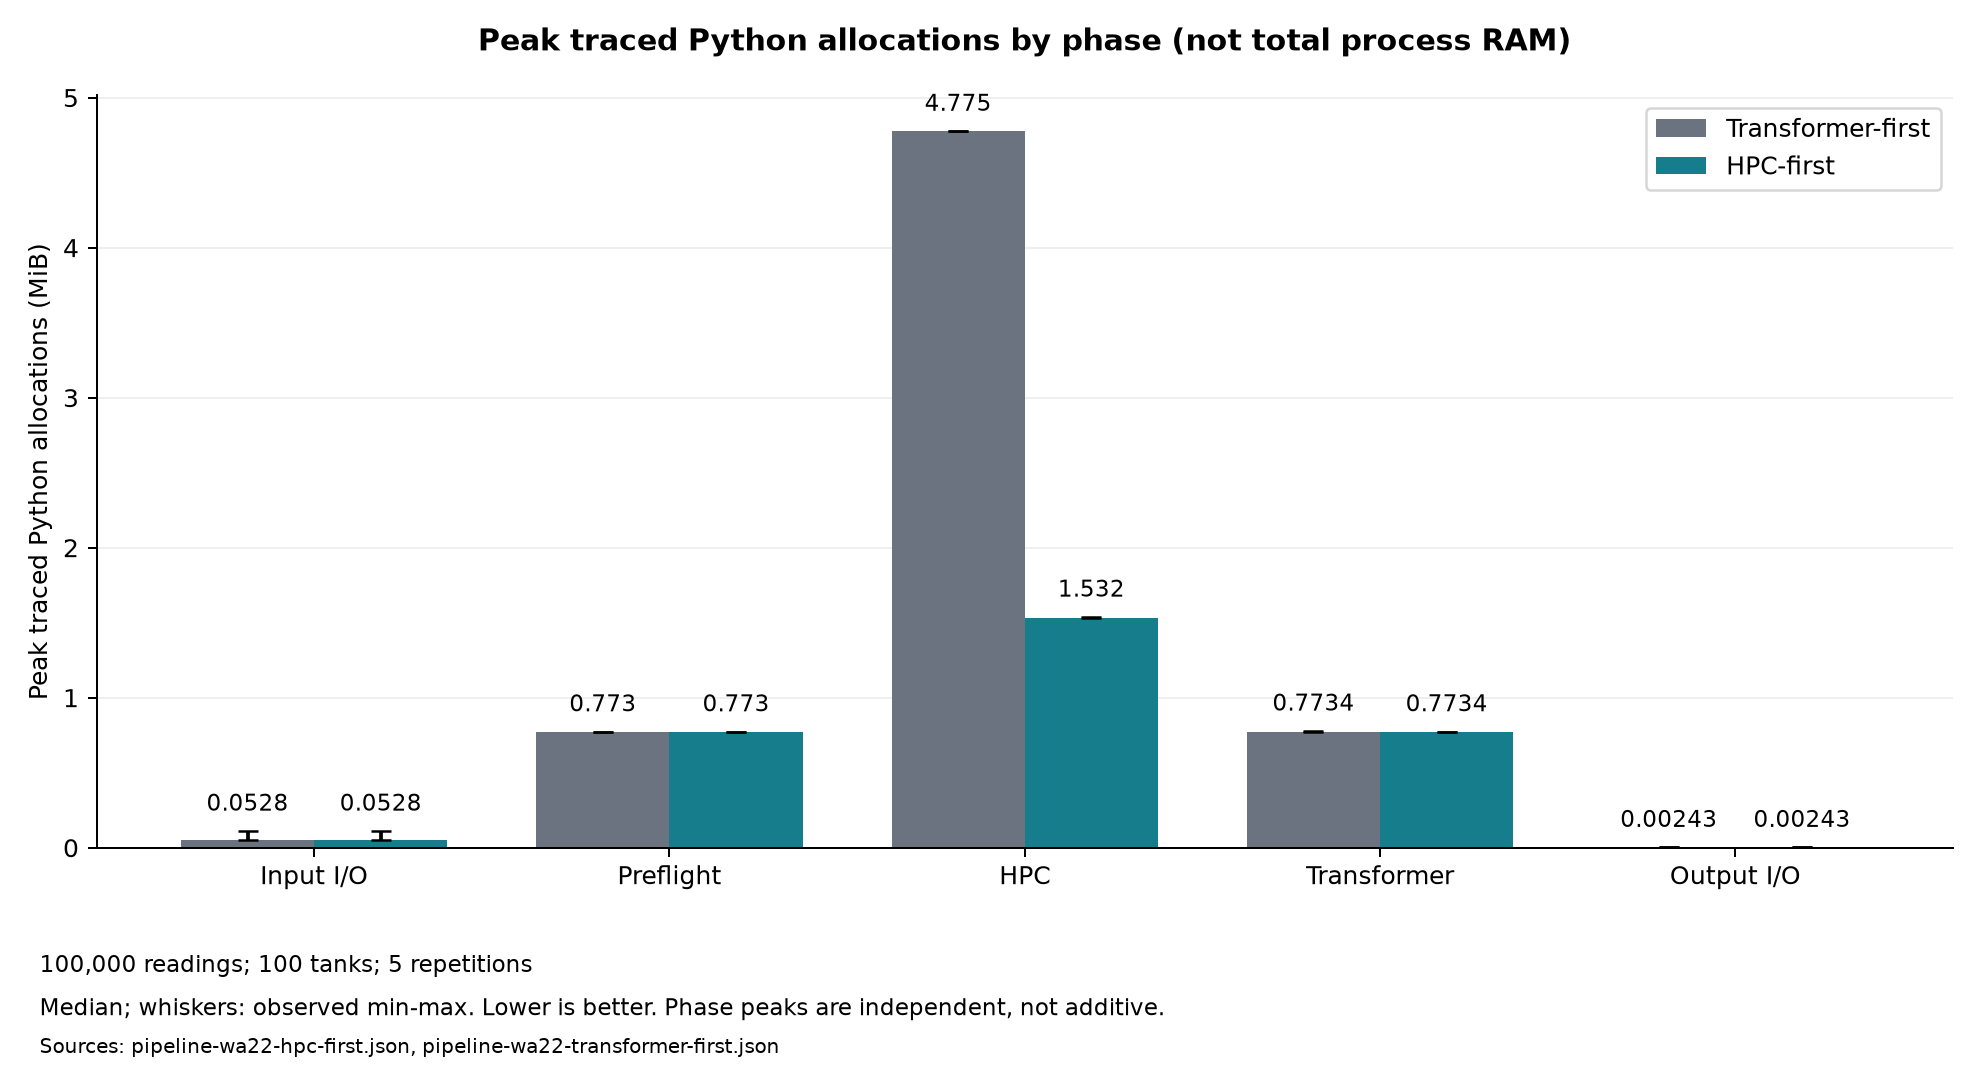

### Confronto dei kernel

Leggere insieme i tempi e la configurazione dell'esperimento. Le varianti condividono formula e dati; compilazione e parallelismo sono i fattori confrontati.

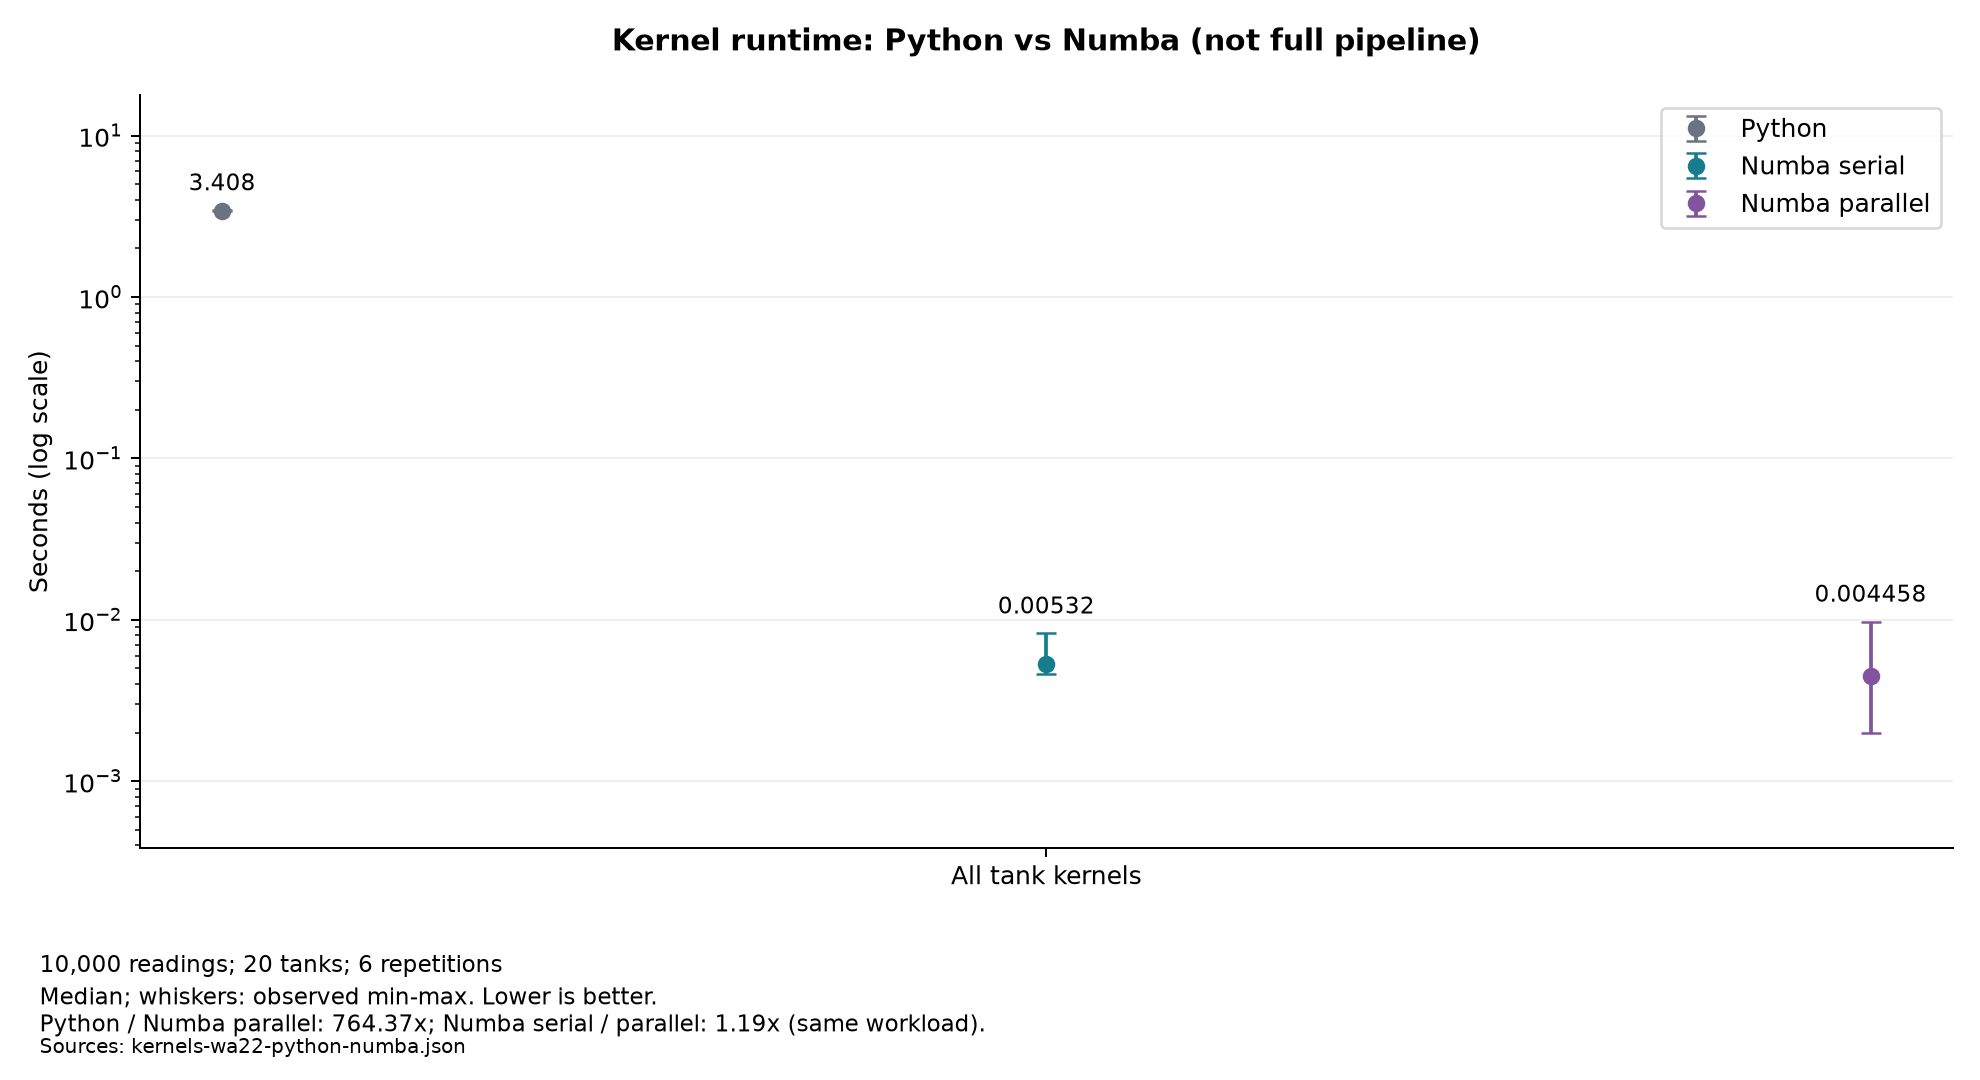

### Cache su disco di Numba

Distinguere la prima chiamata con cache vuota, quella con cache popolata e l'esecuzione a caldo. La cache riutilizza il codice compilato, non il risultato dello stress.

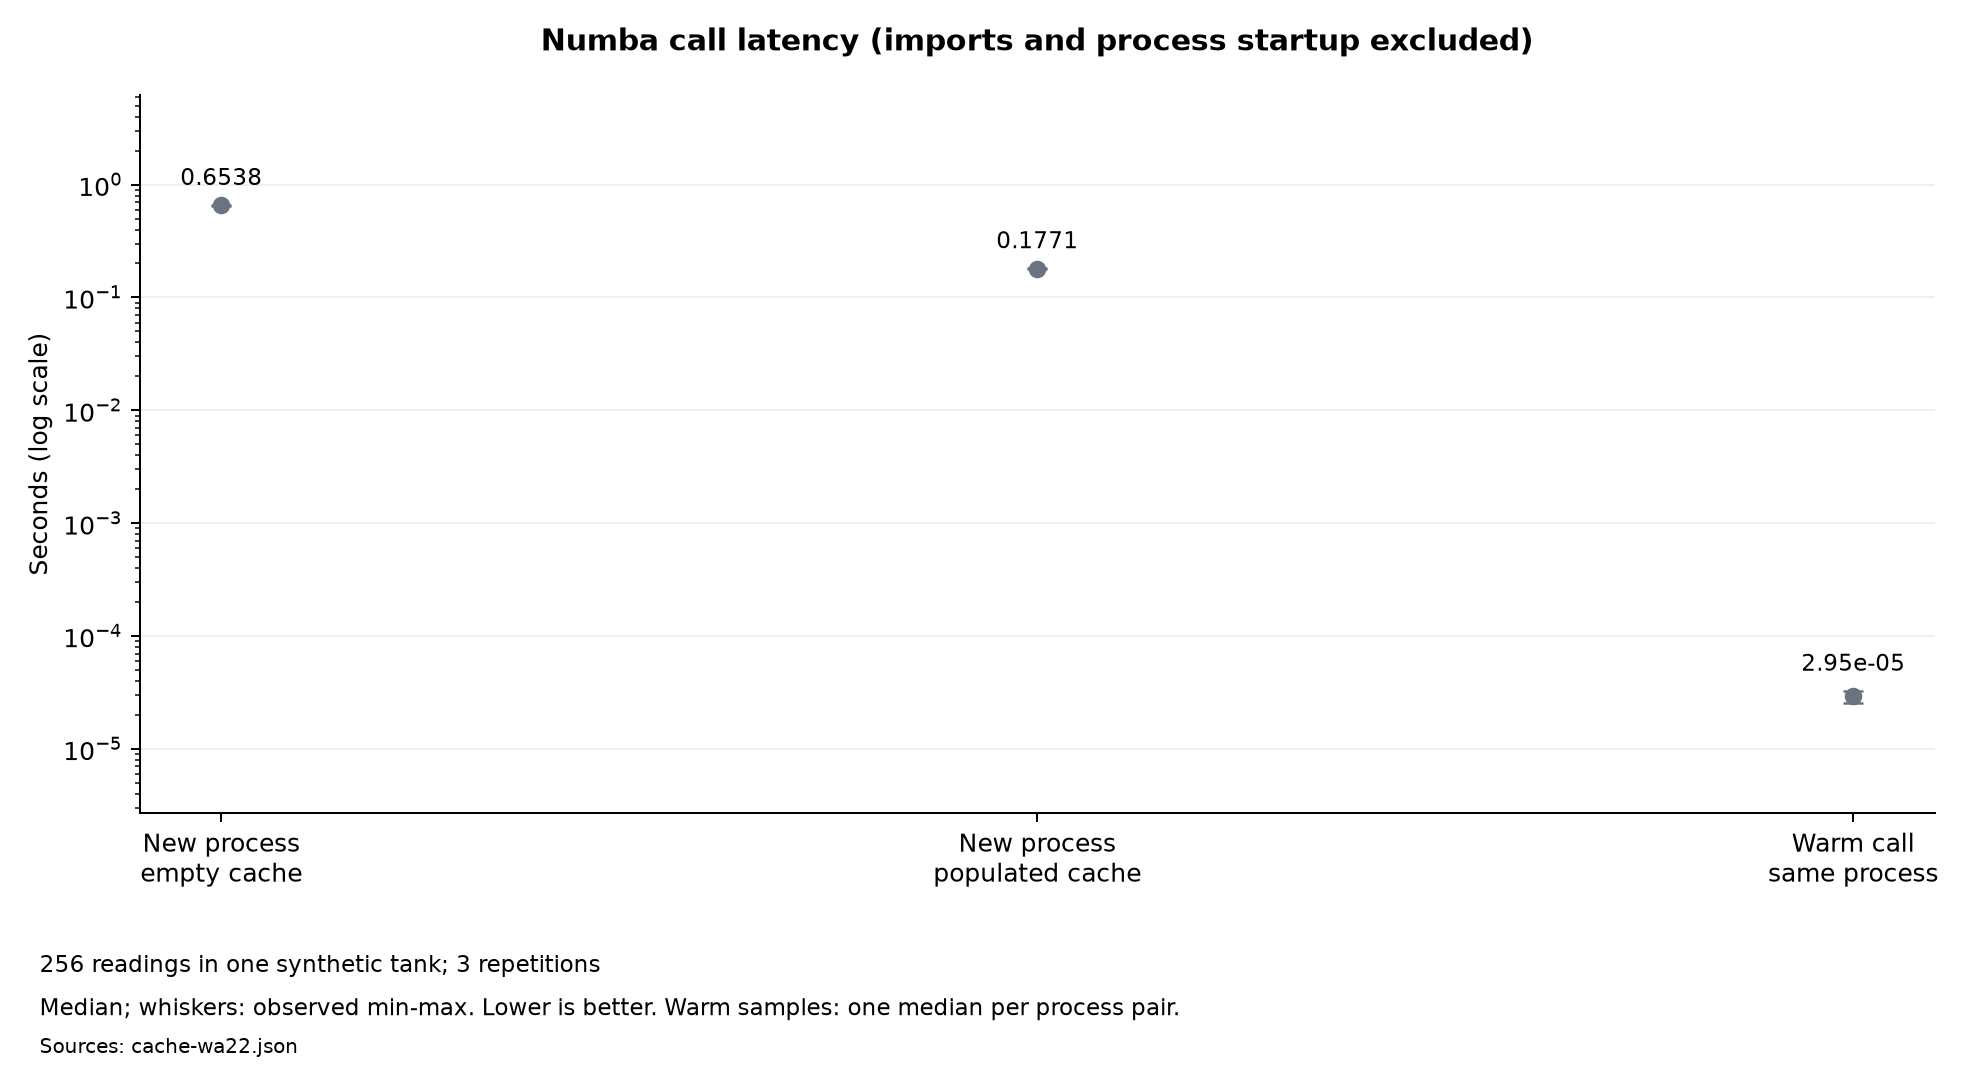

### Generazione dei dati con Joblib

Confrontare prima chiamata e chiamata successiva al variare dei worker. L'esperimento riguarda il generatore: il costo di avvio dei processi può rendere il parallelismo meno conveniente per carichi piccoli.

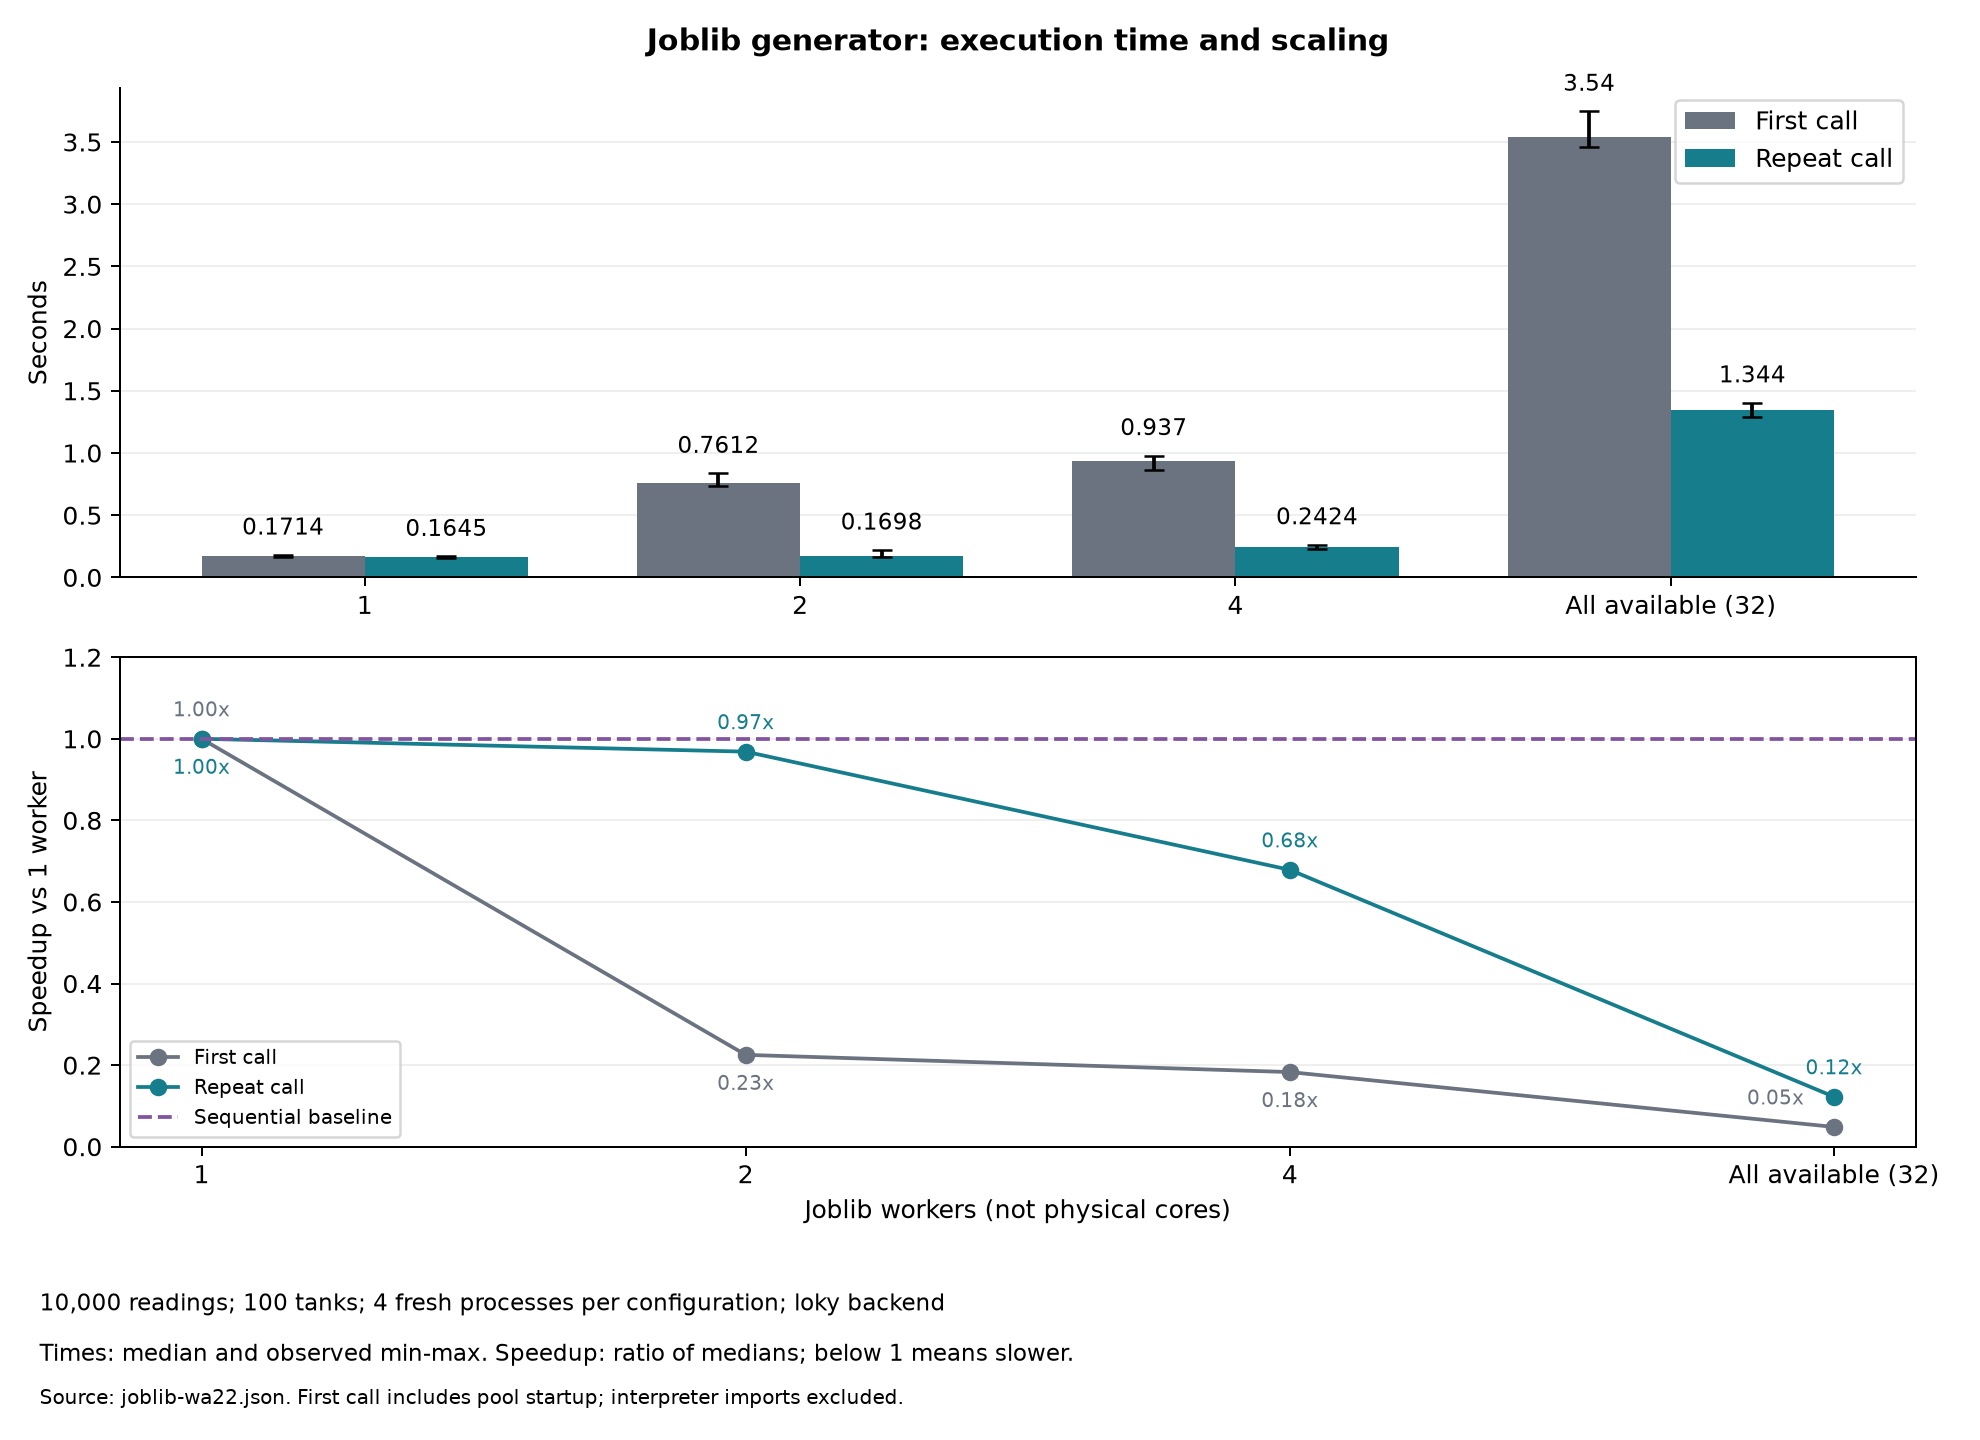

In [15]:
additional_plots = [
    (
        "Memoria Python tracciata", "docs/performance-plots/pipeline-memory.png",
        "Osservare il picco nella fase HPC prima e dopo il riordino. La misura usa "
        "tracemalloc e non comprende tutte le allocazioni native di Polars, NumPy e Numba.",
    ),
    (
        "Confronto dei kernel", "docs/performance-plots/kernel-parallelism.png",
        "Leggere insieme i tempi e la configurazione dell'esperimento. Le varianti "
        "condividono formula e dati; compilazione e parallelismo sono i fattori confrontati.",
    ),
    (
        "Cache su disco di Numba", "docs/performance-plots/numba-cache.png",
        "Distinguere la prima chiamata con cache vuota, quella con cache popolata e "
        "l'esecuzione a caldo. La cache riutilizza il codice compilato, non il risultato dello stress.",
    ),
    (
        "Generazione dei dati con Joblib", "docs/performance-plots/joblib-scaling.png",
        "Confrontare prima chiamata e chiamata successiva al variare dei worker. "
        "L'esperimento riguarda il generatore: il costo di avvio dei processi può rendere "
        "il parallelismo meno conveniente per carichi piccoli.",
    ),
]
for description, image_path, reading_note in additional_plots:
    display(Markdown(f"### {description}\n\n{reading_note}"))
    display(Image(filename=image_path, width=800))